In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df_germany = df[df['job_country'] == 'Germany'].copy()

df_germany['job_posted_month'] = df_germany['job_posted_date'].dt.strftime('%B')

df_de_pivot = df_germany.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)

df_de_pivot.reset_index(inplace=True)
df_de_pivot['month_number'] = pd.to_datetime(df_de_pivot['job_posted_month'], format='%B').dt.month

df_de_pivot.sort_values('month_number', inplace=True)
df_de_pivot.set_index('job_posted_month', inplace=True)
df_de_pivot.drop('month_number', axis=1, inplace=True)

df_de_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,46,11,596,622,759,39,128,239,205,52
February,49,11,593,571,611,35,131,199,171,60
March,43,3,582,511,529,18,86,199,157,42
April,47,13,454,432,520,17,93,190,146,20
May,45,7,430,364,351,16,81,123,111,29
June,31,7,558,434,430,22,92,137,138,30
July,46,7,545,474,438,25,105,143,125,50
August,28,9,489,399,407,30,86,145,141,48
September,106,24,656,668,583,41,126,178,137,66


In [6]:
df_de_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col='job_posted_month')

df_de_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [8]:
df_de_merged = df_de_pivot.merge(df_de_software_pivot, on='job_posted_month')

In [ ]:
top_5 = (
    df_de_merged.sum()
    .sort_values(ascending=False)
    .head()
    .index # gets the index (job titles) of the top 5
    .tolist()
)

top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Analyst']

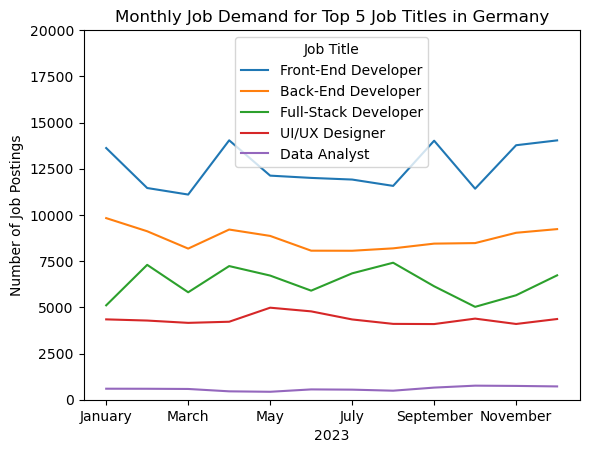

In [14]:
df_de_merged[top_5].plot(kind='line')
plt.title('Monthly Job Demand for Top 5 Job Titles in Germany')
plt.xlabel('2023')
plt.ylabel('Number of Job Postings')
plt.ylim(0, 20000) # set y-axis limit for better visualization
plt.legend(title='Job Title')
plt.show()